In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from sklearn.metrics import matthews_corrcoef, confusion_matrix

In [2]:
path = "/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_first_order_SHAP_analysis/outputs/dpsi_vs_local_SHAP/all_partitions/dpsi_vs_local_SHAP_scatterplot_data_all_partitions.tsv.gz"

In [3]:
table = pd.read_csv(path, sep='\t', compression='gzip')

In [6]:
table

,Feature,RBP_KD_Target,Position,rMATS Event ID,dPSI,rMATS FDR,Bound Local SHAP,CTRL - KD Local SHAP,CTRL - KD Model Prediction (Probability),Cell Line
0,AKAP1_1_binding,AKAP1,1,2137,-0.002,1.000000,0.356984,0.357133,0.000065,HepG2
1,AKAP1_1_binding,AKAP1,1,3895,-0.000,1.000000,0.376375,0.376532,0.000175,HepG2
2,AKAP1_1_binding,AKAP1,1,6307,0.038,0.019931,0.384961,0.385121,0.004527,HepG2
3,AKAP1_1_binding,AKAP1,1,14700,-0.001,1.000000,0.418992,0.419167,0.002355,HepG2
4,AKAP1_1_binding,AKAP1,1,31976,-0.000,1.000000,0.396195,0.396361,0.000169,HepG2
...,...,...,...,...,...,...,...,...,...,...
250280,ZRANB2_6_binding,ZRANB2,6,5756,0.006,1.000000,0.000000,0.000000,0.000000,K562
250281,ZRANB2_6_binding,ZRANB2,6,9960,0.002,1.000000,0.000000,0.000000,0.000052,K562
250282,ZRANB2_6_binding,ZRANB2,6,39013,0.002,1.000000,0.000000,0.000000,0.000000,K562
250283,ZRANB2_6_binding,ZRANB2,6,43918,-0.003,1.000000,0.000000,0.000000,0.000000,K562


## Make confusion matrix and scatterplot for one feature

In [7]:
def per_feature_MMC(data, feature):
    """
    Calculates MCC for delta SHAP (+ or -) and dPSI (+ or -) and renders
    a figure with: confusion matrix | MCC bar | scatterplot — one row per cell line.

    Parameters:
    -----------
    data : DataFrame
        Input dataframe containing the data. Expected columns:
          'Cell Line', 'Feature', 'dPSI', 'rMATS FDR', 'CTRL - KD Local SHAP'
    feature : str
        Feature name (e.g., 'RBFOX2_3_binding')
    """

    cell_lines = ['HepG2', 'K562']

    # Parse feature name (format: RBP_position_binding)
    parts = feature.split('_')
    rbp_name = parts[0]
    position = parts[1]
    parsed_title = f"{rbp_name} Position {position}"

    plt.style.use(
        "/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/"
        "analysis/07_reece_biological_validations/paper.mplstyle"
    )

    fig, axes = plt.subplots(
        nrows=len(cell_lines), ncols=2,
        figsize=(12, 6 * len(cell_lines)),
        gridspec_kw={'width_ratios': [1, 1.2]}
    )
    if len(cell_lines) == 1:
        axes = axes[np.newaxis, :]

    for idx, cell_line in enumerate(cell_lines):

        # ------------------------------------------------------------------
        # 1. Subset & significance filter
        # ------------------------------------------------------------------
        feature_subset = data[
            (data['Cell Line'] == cell_line) &
            (data['Feature'] == feature)
        ].copy()

        feature_subset['Significance'] = (
            (feature_subset['dPSI'].abs() > 0) &
            (feature_subset['rMATS FDR'] <= 0.1)
        ).astype(int)

        significant_subset = feature_subset[feature_subset['Significance'] == 1].copy()
        num_significant = len(significant_subset)

        # ------------------------------------------------------------------
        # 2. MCC calculation (requires ≥ 10 significant events)
        # ------------------------------------------------------------------
        ax_cm   = axes[idx, 0]
        ax_scat = axes[idx, 1]

        if num_significant >= 10:
            # Ground truth  → sign of dPSI   (+1 / -1)
            # Predicted     → sign of SHAP   (+1 / -1)
            y_true = np.sign(significant_subset['dPSI'].values).astype(int)
            y_pred = np.sign(significant_subset['CTRL - KD Local SHAP'].values).astype(int)

            mcc = matthews_corrcoef(y_true, y_pred)

            print(f"The MMC is {mcc}")

            # Confusion matrix  (labels order: -1 then +1 for readability)
            labels = [-1, 1]
            cm = confusion_matrix(y_true, y_pred, labels=labels)

            # ── Confusion matrix heatmap ───────────────────────────────────
            im = ax_cm.imshow(cm, interpolation='nearest', cmap='Blues',
                              vmin=0, vmax=cm.max())
            plt.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)

            tick_labels = ['−', '+']
            ax_cm.set_xticks([0, 1]); ax_cm.set_xticklabels(tick_labels, fontsize=13)
            ax_cm.set_yticks([0, 1]); ax_cm.set_yticklabels(tick_labels, fontsize=13)
            ax_cm.set_xlabel(r"Predicted sign of $\Delta\varphi$", fontsize=13, labelpad=8)
            ax_cm.set_ylabel(r"True sign of $\Delta\Psi$",          fontsize=13, labelpad=8)
            ax_cm.set_title("Confusion Matrix", fontsize=15, pad=12)

            # Annotate each cell with count
            thresh = cm.max() / 2.0
            for i in range(2):
                for j in range(2):
                    ax_cm.text(j, i, str(cm[i, j]),
                               ha='center', va='center', fontsize=15,
                               color='white' if cm[i, j] > thresh else 'black')

            ax_cm.text(0.5, -0.18,
                       f"n = {num_significant} significant events",
                       transform=ax_cm.transAxes,
                       ha='center', fontsize=11, color='dimgrey')

        # ------------------------------------------------------------------
        # 3. Scatter plot
        # ------------------------------------------------------------------
        if len(feature_subset) > 0:
            colors = [
                'tab:blue' if (abs(dpsi) > 0 and fdr <= 0.1) else 'lightgrey'
                for dpsi, fdr in zip(feature_subset['dPSI'],
                                     feature_subset['rMATS FDR'])
            ]
            ax_scat.scatter(
                feature_subset['CTRL - KD Local SHAP'],
                feature_subset['dPSI'],
                c=colors, alpha=0.5, s=30
            )

            # Sign-concordance annotation (blue points only)
            if num_significant >= 10:
                shap_vals = significant_subset['CTRL - KD Local SHAP']
                dpsi_vals = significant_subset['dPSI']
                same_sign = (
                    ((shap_vals > 0) & (dpsi_vals > 0)) |
                    ((shap_vals < 0) & (dpsi_vals < 0))
                )
                sign_concordance = same_sign.sum() / num_significant * 100

                textstr = (
                    f"Sign concordance: {sign_concordance:.1f}%\n"
                    f"MCC: {mcc:.3f}"
                )
                props = dict(boxstyle='round', facecolor='white',
                             edgecolor='black', alpha=0.8)
                ax_scat.text(0.05, 0.05, textstr,
                             transform=ax_scat.transAxes,
                             fontsize=13, verticalalignment='bottom',
                             bbox=props)

        ax_scat.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
        ax_scat.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
        ax_scat.grid(True, alpha=0.3)
        ax_scat.set_xlabel(r"$\Delta\varphi$",            fontsize=14, labelpad=10)
        ax_scat.set_ylabel(r"$\Delta\Psi$",               fontsize=14, labelpad=10)
        ax_scat.set_title(r"$\Delta\varphi$ vs. $\Delta\Psi$", fontsize=16, pad=15)
        ax_scat.tick_params(axis='both', labelsize=12)

        # Cell-line row label
        axes[idx, 0].text(
            -0.25, 0.5, cell_line,
            transform=axes[idx, 0].transAxes,
            fontsize=20, fontweight='bold',
            rotation=90, va='center', ha='center'
        )

    fig.suptitle(parsed_title, fontsize=18, y=1.002)
    plt.tight_layout()
    plt.show()

The MMC is 0.0


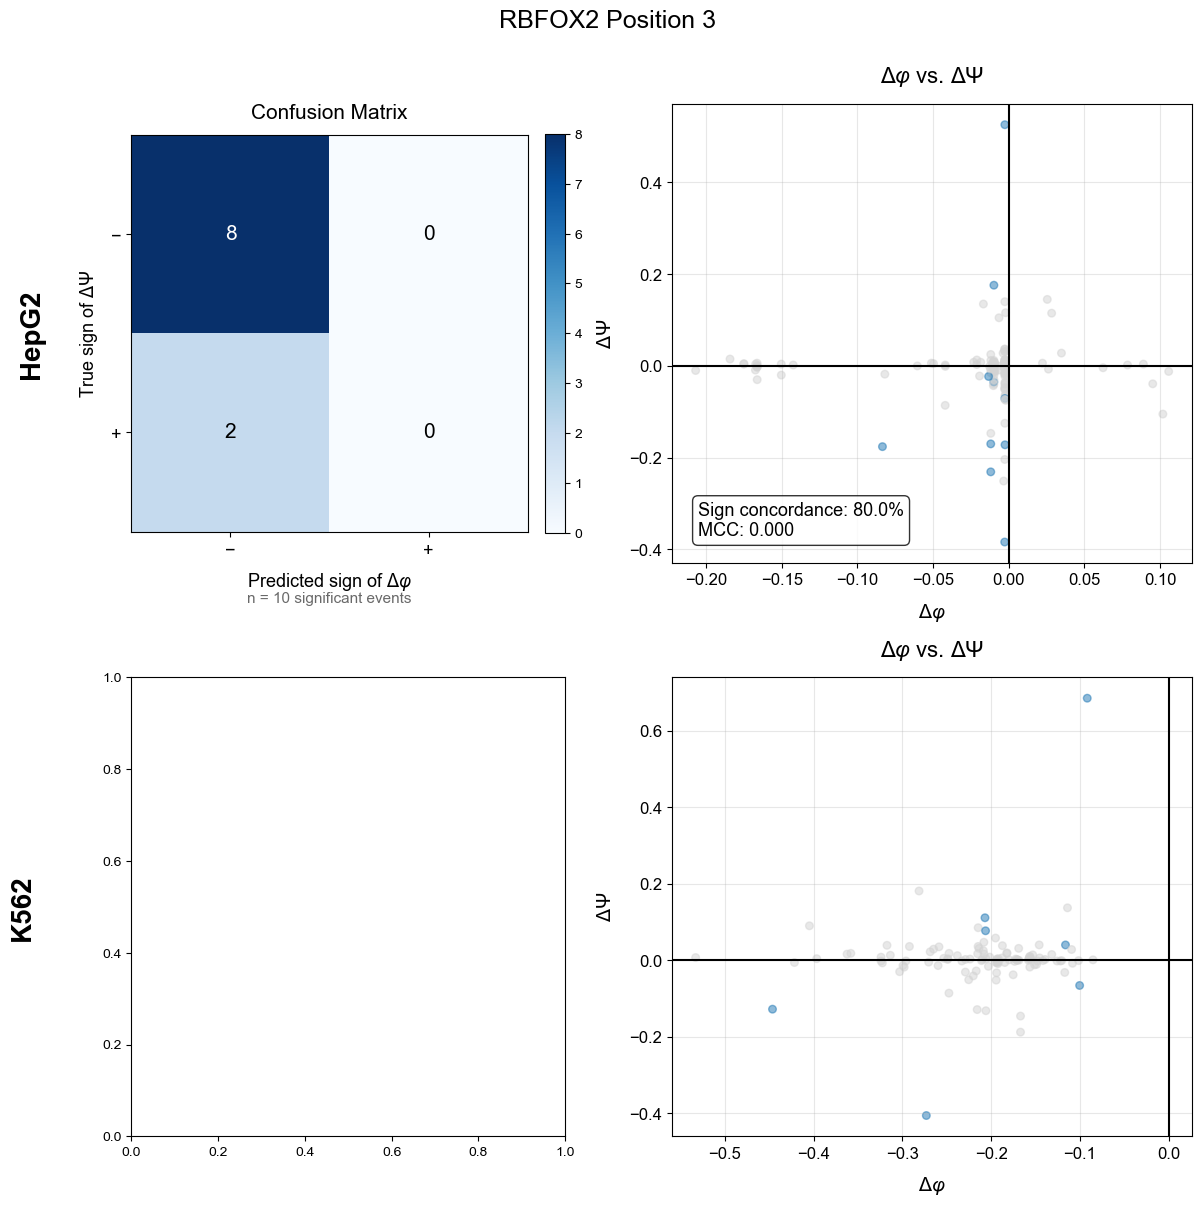

In [8]:
per_feature_MMC(table, 'RBFOX2_3_binding')

## Generate figure 4

In [5]:
K562_features = ["METAP2_5_binding", "BUD13_6_binding", "YBX3_1_binding"]

In [9]:
HepG2_features = ["EFTUD2_4_binding", "UCHL5_1_binding", "EFTUD2_1_binding"]

In [ ]:
# make one version with scale bar locked and another with flexible

In [10]:
def top_feature_MCC(data, K562_feature_list, HepG2_feature_list):
    """
    Creates a 2x3 figure of CTRL - KD Local SHAP vs dPSI scatterplots.
    One row per cell line (HepG2, K562), one column per feature (3 features each).
    MCC value is annotated in the corner of each scatterplot.

    Parameters:
    -----------
    data : DataFrame
        Input dataframe containing the data. Expected columns:
          'Cell Line', 'Feature', 'dPSI', 'rMATS FDR', 'CTRL - KD Local SHAP'
    K562_feature_list : list
        List of 3 feature names for the K562 cell line.
    HepG2_feature_list : list
        List of 3 feature names for the HepG2 cell line.
    """

    plt.style.use(
        "/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/"
        "analysis/07_reece_biological_validations/paper.mplstyle"
    )

    cell_lines = ['HepG2', 'K562']
    feature_lists = {
        'HepG2': HepG2_feature_list,
        'K562':  K562_feature_list,
    }

    fig, axes = plt.subplots(
        nrows=2, ncols=3,
        figsize=(18, 10),
    )

    for row_idx, cell_line in enumerate(cell_lines):
        features = feature_lists[cell_line]

        for col_idx, feature in enumerate(features):
            ax = axes[row_idx, col_idx]

            # ------------------------------------------------------------------
            # 1. Subset & significance filter
            # ------------------------------------------------------------------
            feature_subset = data[
                (data['Cell Line'] == cell_line) &
                (data['Feature'] == feature)
            ].copy()

            feature_subset['Significance'] = (
                (feature_subset['dPSI'].abs() > 0) &
                (feature_subset['rMATS FDR'] <= 0.1)
            ).astype(int)

            significant_subset = feature_subset[feature_subset['Significance'] == 1].copy()
            num_significant = len(significant_subset)

            # ------------------------------------------------------------------
            # 2. Scatter plot
            # ------------------------------------------------------------------
            if len(feature_subset) > 0:
                colors = [
                    'tab:blue' if (abs(dpsi) > 0 and fdr <= 0.1) else 'lightgrey'
                    for dpsi, fdr in zip(feature_subset['dPSI'],
                                         feature_subset['rMATS FDR'])
                ]
                ax.scatter(
                    feature_subset['CTRL - KD Local SHAP'],
                    feature_subset['dPSI'],
                    c=colors, alpha=0.5, s=30
                )

            # ------------------------------------------------------------------
            # 3. MCC annotation (requires ≥ 10 significant events)
            # ------------------------------------------------------------------
            if num_significant >= 10:
                y_true = np.sign(significant_subset['dPSI'].values).astype(int)
                y_pred = np.sign(significant_subset['CTRL - KD Local SHAP'].values).astype(int)
                mcc = matthews_corrcoef(y_true, y_pred)

                shap_vals = significant_subset['CTRL - KD Local SHAP']
                dpsi_vals = significant_subset['dPSI']
                same_sign = (
                    ((shap_vals > 0) & (dpsi_vals > 0)) |
                    ((shap_vals < 0) & (dpsi_vals < 0))
                )
                sign_concordance = same_sign.sum() / num_significant * 100

                textstr = f"Sign concordance: {sign_concordance:.1f}%\nMCC: {mcc:.3f}"
                props = dict(boxstyle='round', facecolor='white',
                             edgecolor='black', alpha=0.8)
                ax.text(0.05, 0.05, textstr,
                        transform=ax.transAxes,
                        fontsize=11, verticalalignment='bottom',
                        bbox=props)
            else:
                ax.text(0.05, 0.05, "n < 10\n(MCC not computed)",
                        transform=ax.transAxes,
                        fontsize=11, verticalalignment='bottom',
                        color='grey')

            # ------------------------------------------------------------------
            # 4. Axes formatting
            # ------------------------------------------------------------------
            ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
            ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
            ax.grid(True, alpha=0.3)
            ax.set_xlabel(r"$\Delta\varphi$ (SHAP)", fontsize=12, labelpad=8)
            ax.set_ylabel(r"$\Delta\Psi$",           fontsize=12, labelpad=8)
            ax.tick_params(axis='both', labelsize=10)

            # Column title: parse feature name (RBP_position_binding → "RBP Position X")
            parts = feature.split('_')
            rbp_name = parts[0]
            position = parts[1] if len(parts) > 1 else ''
            col_title = f"{rbp_name} Position {position}"
            ax.set_title(col_title, fontsize=13, pad=10)

        # Row label (cell line name on the left)
        axes[row_idx, 0].annotate(
            cell_line,
            xy=(-0.25, 0.5), xycoords='axes fraction',
            fontsize=16, fontweight='bold',
            rotation=90, va='center', ha='center'
        )

    fig.suptitle(r"$\Delta\varphi$ vs. $\Delta\Psi$ by Feature and Cell Line",
                 fontsize=18, y=1.01)
    plt.tight_layout()
    plt.show()

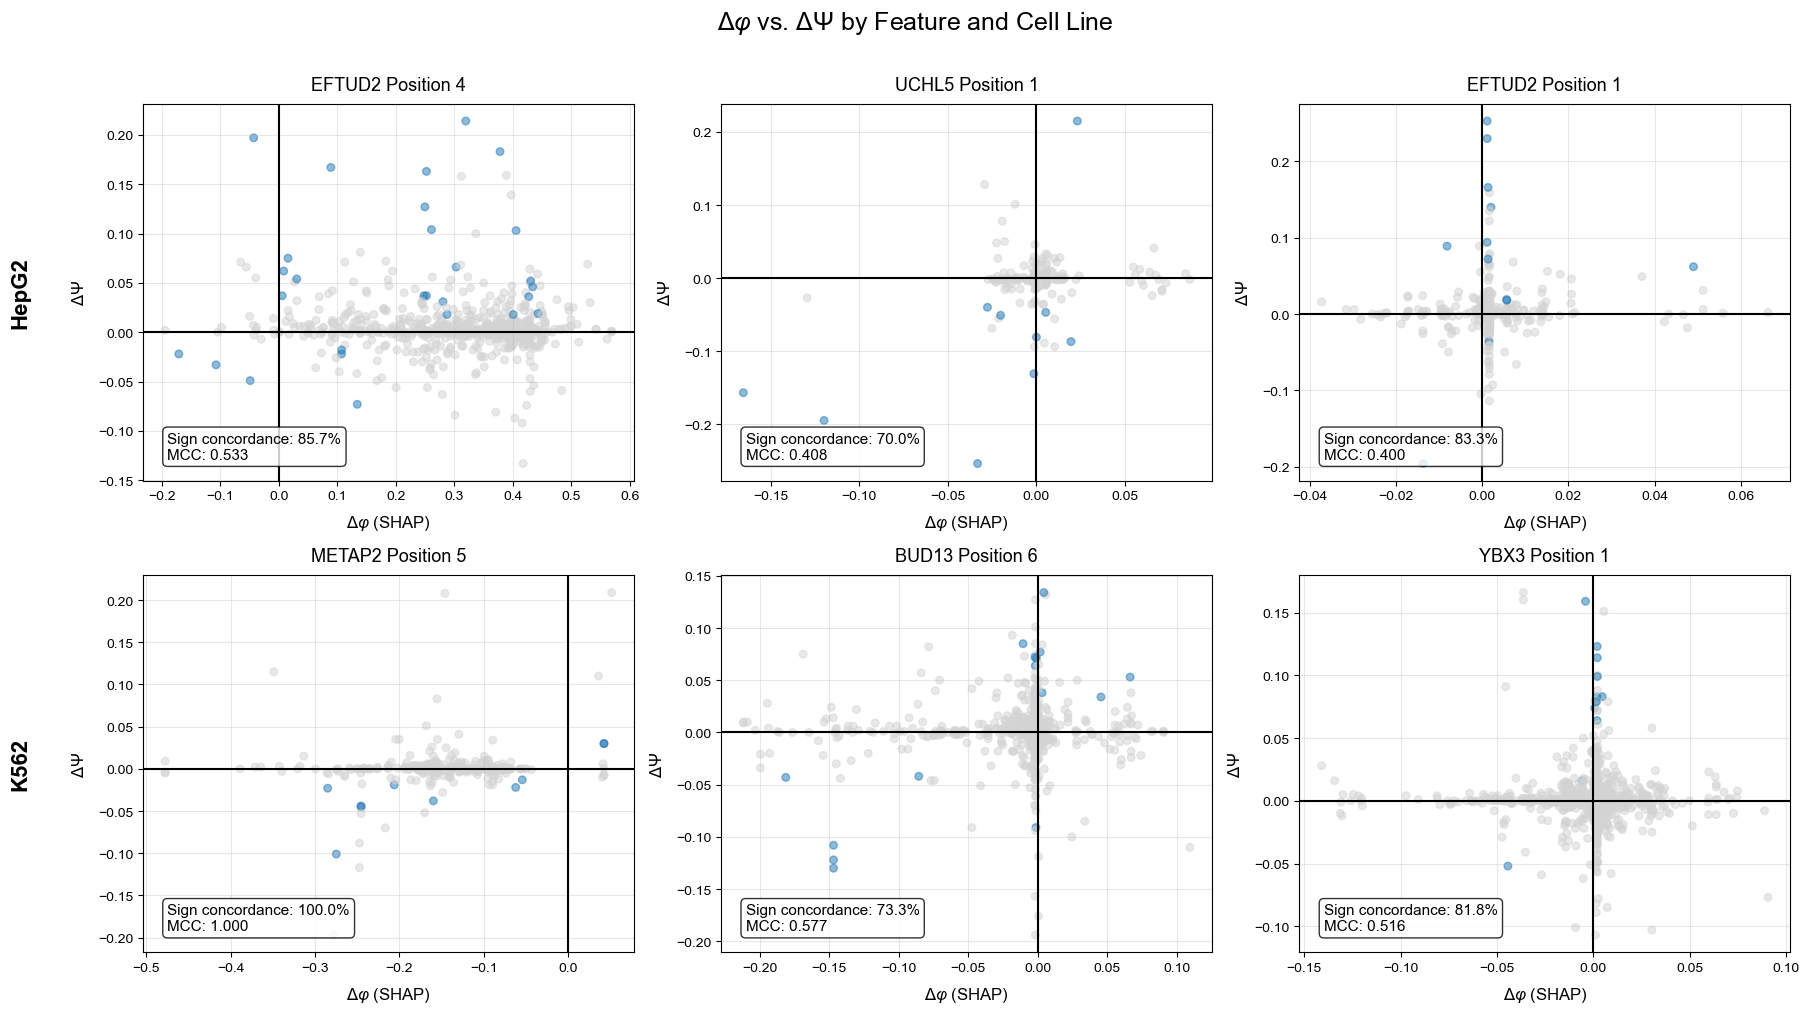

In [11]:
top_feature_MCC(table, K562_features, HepG2_features)

In [ ]:
## Fixed scale bars

In [12]:
def top_feature_MCC_scaled(data, K562_feature_list, HepG2_feature_list):
    """
    Creates a 2x3 figure of CTRL - KD Local SHAP vs dPSI scatterplots.
    One row per cell line (HepG2, K562), one column per feature (3 features each).
    All plots share the same x and y axis limits (global min/max across all features).
    MCC value is annotated in the corner of each scatterplot.

    Parameters:
    -----------
    data : DataFrame
        Input dataframe containing the data. Expected columns:
          'Cell Line', 'Feature', 'dPSI', 'rMATS FDR', 'CTRL - KD Local SHAP'
    K562_feature_list : list
        List of 3 feature names for the K562 cell line.
    HepG2_feature_list : list
        List of 3 feature names for the HepG2 cell line.
    """

    plt.style.use(
        "/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/"
        "analysis/07_reece_biological_validations/paper.mplstyle"
    )

    cell_lines = ['HepG2', 'K562']
    feature_lists = {
        'HepG2': HepG2_feature_list,
        'K562':  K562_feature_list,
    }
    all_features = HepG2_feature_list + K562_feature_list

    # ------------------------------------------------------------------
    # 1. Compute global axis limits across all cell lines and features
    # ------------------------------------------------------------------
    all_subsets = []
    for cell_line in cell_lines:
        for feature in feature_lists[cell_line]:
            subset = data[
                (data['Cell Line'] == cell_line) &
                (data['Feature'] == feature)
            ]
            all_subsets.append(subset)

    combined = pd.concat(all_subsets, ignore_index=True)

    shap_min = combined['CTRL - KD Local SHAP'].min()
    shap_max = combined['CTRL - KD Local SHAP'].max()
    dpsi_min = combined['dPSI'].min()
    dpsi_max = combined['dPSI'].max()

    # Add a small padding (5%) so points on the edge aren't clipped
    shap_pad = (shap_max - shap_min) * 0.05
    dpsi_pad = (dpsi_max - dpsi_min) * 0.05

    x_lim = (shap_min - shap_pad, shap_max + shap_pad)
    y_lim = (dpsi_min - dpsi_pad, dpsi_max + dpsi_pad)

    # ------------------------------------------------------------------
    # 2. Build figure
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(
        nrows=2, ncols=3,
        figsize=(18, 10),
        sharex=True, sharey=True       # enforces shared scale visually
    )

    for row_idx, cell_line in enumerate(cell_lines):
        features = feature_lists[cell_line]

        for col_idx, feature in enumerate(features):
            ax = axes[row_idx, col_idx]

            # --------------------------------------------------------------
            # Subset & significance filter
            # --------------------------------------------------------------
            feature_subset = data[
                (data['Cell Line'] == cell_line) &
                (data['Feature'] == feature)
            ].copy()

            feature_subset['Significance'] = (
                (feature_subset['dPSI'].abs() > 0) &
                (feature_subset['rMATS FDR'] <= 0.1)
            ).astype(int)

            significant_subset = feature_subset[feature_subset['Significance'] == 1].copy()
            num_significant = len(significant_subset)

            # --------------------------------------------------------------
            # Scatter plot
            # --------------------------------------------------------------
            if len(feature_subset) > 0:
                colors = [
                    'tab:blue' if (abs(dpsi) > 0 and fdr <= 0.1) else 'lightgrey'
                    for dpsi, fdr in zip(feature_subset['dPSI'],
                                         feature_subset['rMATS FDR'])
                ]
                ax.scatter(
                    feature_subset['CTRL - KD Local SHAP'],
                    feature_subset['dPSI'],
                    c=colors, alpha=0.5, s=30
                )

            # Explicitly set shared limits (sharex/sharey handles it,
            # but setting explicitly ensures consistency if any panel is empty)
            ax.set_xlim(x_lim)
            ax.set_ylim(y_lim)

            # --------------------------------------------------------------
            # MCC annotation
            # --------------------------------------------------------------
            if num_significant >= 10:
                y_true = np.sign(significant_subset['dPSI'].values).astype(int)
                y_pred = np.sign(significant_subset['CTRL - KD Local SHAP'].values).astype(int)
                mcc = matthews_corrcoef(y_true, y_pred)

                shap_vals = significant_subset['CTRL - KD Local SHAP']
                dpsi_vals = significant_subset['dPSI']
                same_sign = (
                    ((shap_vals > 0) & (dpsi_vals > 0)) |
                    ((shap_vals < 0) & (dpsi_vals < 0))
                )
                sign_concordance = same_sign.sum() / num_significant * 100

                textstr = f"Sign concordance: {sign_concordance:.1f}%\nMCC: {mcc:.3f}"
                props = dict(boxstyle='round', facecolor='white',
                             edgecolor='black', alpha=0.8)
                ax.text(0.05, 0.05, textstr,
                        transform=ax.transAxes,
                        fontsize=11, verticalalignment='bottom',
                        bbox=props)
            else:
                ax.text(0.05, 0.05, "n < 10\n(MCC not computed)",
                        transform=ax.transAxes,
                        fontsize=11, verticalalignment='bottom',
                        color='grey')

            # --------------------------------------------------------------
            # Axes formatting
            # --------------------------------------------------------------
            ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
            ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', labelsize=10)

            # Only label outer axes to avoid clutter with shared scales
            if row_idx == 1:
                ax.set_xlabel(r"$\Delta\varphi$ (SHAP)", fontsize=12, labelpad=8)
            if col_idx == 0:
                ax.set_ylabel(r"$\Delta\Psi$", fontsize=12, labelpad=8)

            # Column title
            parts = feature.split('_')
            rbp_name = parts[0]
            position = parts[1] if len(parts) > 1 else ''
            col_title = f"{rbp_name} Position {position}"
            ax.set_title(col_title, fontsize=13, pad=10)

        # Row label
        axes[row_idx, 0].annotate(
            cell_line,
            xy=(-0.25, 0.5), xycoords='axes fraction',
            fontsize=16, fontweight='bold',
            rotation=90, va='center', ha='center'
        )

    fig.suptitle(r"$\Delta\varphi$ vs. $\Delta\Psi$ by Feature and Cell Line",
                 fontsize=18, y=1.01)
    plt.tight_layout()
    plt.show()

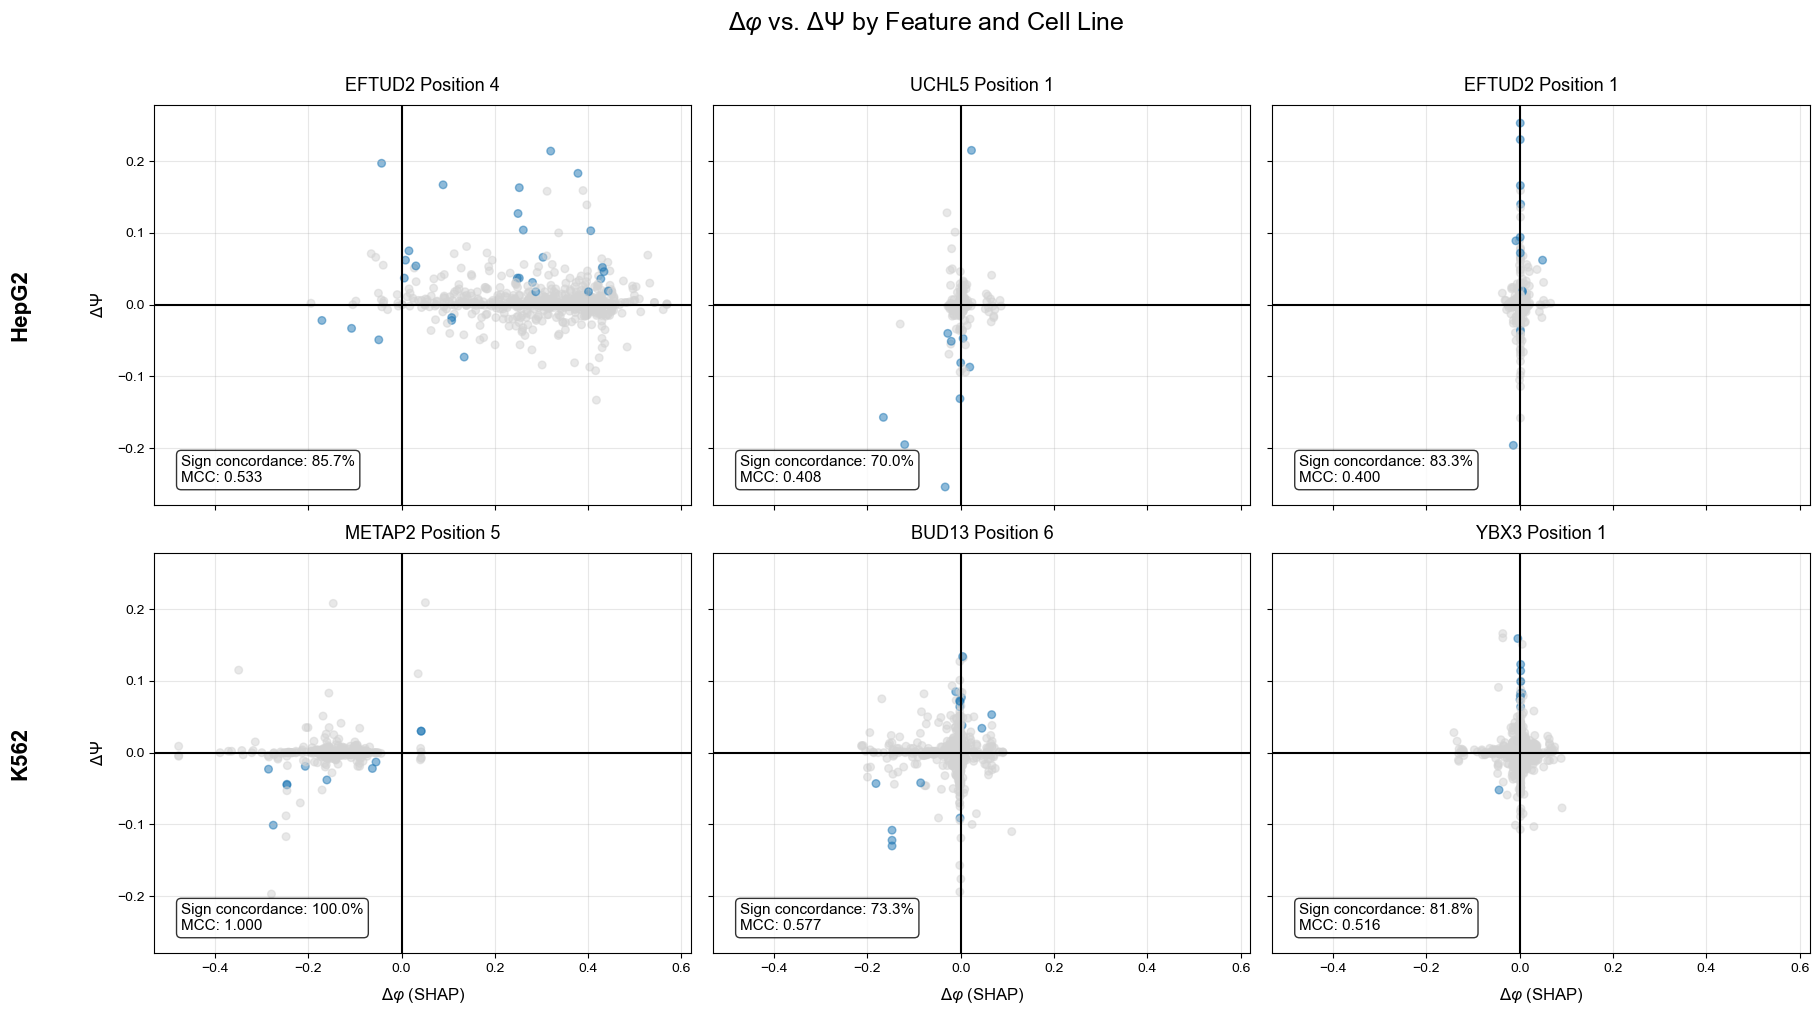

In [14]:
top_feature_MCC_scaled(table, K562_features, HepG2_features)

In [ ]:
## Yogi Color version

In [18]:
def top_feature_MCC_colors(data, K562_feature_list, HepG2_feature_list):
    """
    Creates a 2x3 figure of CTRL - KD Local SHAP vs dPSI scatterplots.
    K562 (top row, #1c95dc) and HepG2 (bottom row, #e8ac26).
    Insignificant points are grey; significant points use cell-line colors.
    MCC and sign concordance are annotated in the corner of each scatterplot.

    Parameters:
    -----------
    data : DataFrame
        Input dataframe containing the data. Expected columns:
          'Cell Line', 'Feature', 'dPSI', 'rMATS FDR', 'CTRL - KD Local SHAP'
    K562_feature_list : list
        List of 3 feature names for the K562 cell line.
    HepG2_feature_list : list
        List of 3 feature names for the HepG2 cell line.
    """

    plt.style.use(
        "/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/"
        "analysis/07_reece_biological_validations/paper.mplstyle"
    )

    cell_lines = ['K562', 'HepG2']          # K562 first → top row
    feature_lists = {
        'K562':  K562_feature_list,
        'HepG2': HepG2_feature_list,
    }
    cell_line_colors = {
        'K562':  '#1c95dc',
        'HepG2': '#e8ac26',
    }

    fig, axes = plt.subplots(
        nrows=2, ncols=3,
        figsize=(18, 10),
    )

    for row_idx, cell_line in enumerate(cell_lines):
        features    = feature_lists[cell_line]
        point_color = cell_line_colors[cell_line]

        for col_idx, feature in enumerate(features):
            ax = axes[row_idx, col_idx]

            # --------------------------------------------------------------
            # Subset & significance filter
            # --------------------------------------------------------------
            feature_subset = data[
                (data['Cell Line'] == cell_line) &
                (data['Feature'] == feature)
            ].copy()

            feature_subset['Significance'] = (
                (feature_subset['dPSI'].abs() > 0) &
                (feature_subset['rMATS FDR'] <= 0.1)
            ).astype(int)

            significant_subset = feature_subset[feature_subset['Significance'] == 1].copy()
            num_significant    = len(significant_subset)

            # --------------------------------------------------------------
            # Scatter plot — insignificant grey, significant cell-line color
            # --------------------------------------------------------------
            if len(feature_subset) > 0:
                insig_mask = feature_subset['Significance'] == 0
                sig_mask   = feature_subset['Significance'] == 1

                # Insignificant points: grey background layer
                ax.scatter(
                    feature_subset.loc[insig_mask, 'CTRL - KD Local SHAP'],
                    feature_subset.loc[insig_mask, 'dPSI'],
                    c='lightgrey', alpha=0.4, s=30, zorder=1,
                    label='Not significant'
                )

                # Significant points: cell-line color
                if sig_mask.any():
                    ax.scatter(
                        feature_subset.loc[sig_mask, 'CTRL - KD Local SHAP'],
                        feature_subset.loc[sig_mask, 'dPSI'],
                        c=point_color, alpha=0.7, s=30, zorder=2,
                        label='Significant'
                    )

            # --------------------------------------------------------------
            # MCC annotation
            # --------------------------------------------------------------
            if num_significant >= 10:
                y_true = np.sign(significant_subset['dPSI'].values).astype(int)
                y_pred = np.sign(significant_subset['CTRL - KD Local SHAP'].values).astype(int)
                mcc    = matthews_corrcoef(y_true, y_pred)

                shap_vals = significant_subset['CTRL - KD Local SHAP']
                dpsi_vals = significant_subset['dPSI']
                same_sign = (
                    ((shap_vals > 0) & (dpsi_vals > 0)) |
                    ((shap_vals < 0) & (dpsi_vals < 0))
                )
                sign_concordance = same_sign.sum() / num_significant * 100

                textstr = f"Sign concordance: {sign_concordance:.1f}%\nMCC: {mcc:.3f}"
                props   = dict(boxstyle='round', facecolor='white',
                               edgecolor='black', alpha=0.8)
                ax.text(0.05, 0.05, textstr,
                        transform=ax.transAxes,
                        fontsize=11, verticalalignment='bottom',
                        bbox=props)
            else:
                ax.text(0.05, 0.05, "n < 10\n(MCC not computed)",
                        transform=ax.transAxes,
                        fontsize=11, verticalalignment='bottom',
                        color='grey')

            # --------------------------------------------------------------
            # Axes formatting
            # --------------------------------------------------------------
            ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
            ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
            ax.grid(True, alpha=0.3)
            ax.set_xlabel(r"$\Delta\varphi$ (SHAP)", fontsize=12, labelpad=8)
            ax.set_ylabel(r"$\Delta\Psi$",           fontsize=12, labelpad=8)
            ax.tick_params(axis='both', labelsize=10)

            # Column title
            parts    = feature.split('_')
            rbp_name = parts[0]
            position = parts[1] if len(parts) > 1 else ''
            ax.set_title(f"{rbp_name} Position {position}", fontsize=13, pad=10)

        # Row label (cell line name on the left, colored to match points)
        axes[row_idx, 0].annotate(
            cell_line,
            xy=(-0.25, 0.5), xycoords='axes fraction',
            fontsize=16, fontweight='bold', color='black',
            rotation=90, va='center', ha='center'
        )

    fig.suptitle(r"$\Delta\varphi$ vs. $\Delta\Psi$ by Feature and Cell Line",
                 fontsize=18, y=1.01)
    plt.tight_layout()
    plt.show()

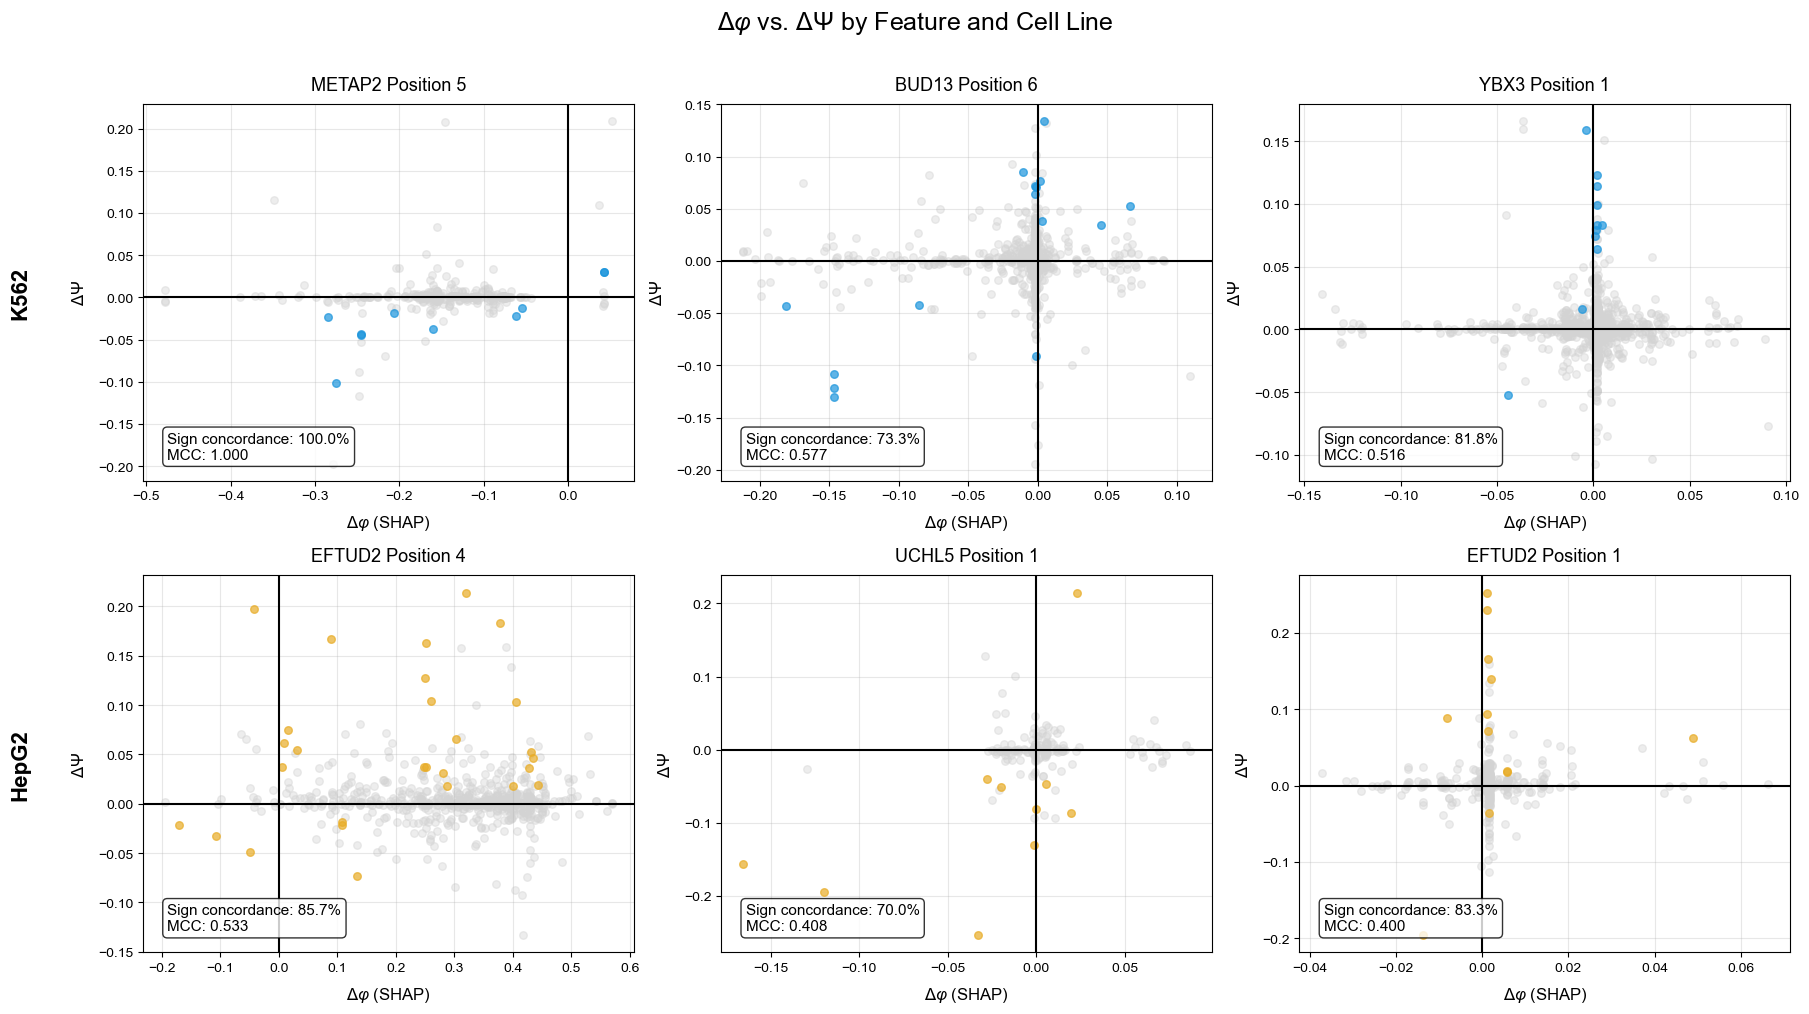

In [19]:
top_feature_MCC_colors(table, K562_features, HepG2_features)

## Summarize data

In [11]:
def summarize_mmc(data):

    cell_lines = ['HepG2', 'K562']
    features = data['Feature'].unique()
    rows = []
    
    for feature in features:
        parts = feature.split('_')
        rbp_name = parts[0]
        position = parts[1]
        rbp_label = f"{rbp_name} Position {position}"

        for cell_line in cell_lines:
    
            # ------------------------------------------------------------------
            # 1. Subset & significance filter
            # ------------------------------------------------------------------
            feature_subset = data[
                (data['Cell Line'] == cell_line) &
                (data['Feature'] == feature)
            ].copy()
    
            feature_subset['Significance'] = (
                (feature_subset['dPSI'].abs() > 0) &
                (feature_subset['rMATS FDR'] <= 0.1)
            ).astype(int)
    
            significant_subset = feature_subset[feature_subset['Significance'] == 1].copy()
            num_significant = len(significant_subset)
    
            # ------------------------------------------------------------------
            # 2. MCC calculation (requires ≥ 10 significant events)
            # ------------------------------------------------------------------
    
            if num_significant >= 10:
                # Ground truth  → sign of dPSI   (+1 / -1)
                # Predicted     → sign of SHAP   (+1 / -1)
                y_true = np.sign(significant_subset['dPSI'].values).astype(int)
                y_pred = np.sign(significant_subset['CTRL - KD Local SHAP'].values).astype(int)
    
                mcc = matthews_corrcoef(y_true, y_pred)
    
                rows.append({
                    'Feature': rbp_label,
                    'Cell Line': cell_line,
                    'Significant Events': num_significant,
                    'MCC': mcc,
                })
    
    return pd.DataFrame(rows).sort_values('MCC', ascending=False).reset_index(drop=True)

In [12]:
test = summarize_mmc(table)

/home/bhd5qr/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/bhd5qr/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
